# Linear Regression

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Data preprocessing

### Data collection


In [2]:
df = pd.read_csv('Data TH_Gold-Prices.csv')

In [3]:
df.describe()

,GPT(THB),GPW(USD),CPI,IR,POIL(USD),EXR
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,23481.250000,1492.038500,100.463750,1.370833,63.729917,33.233936
std,4802.441879,297.166848,3.565235,0.564145,20.007970,1.808449
min,18000.000000,1057.800000,96.650000,0.500000,19.330000,29.985700
25%,19700.000000,1247.010000,97.997500,0.937500,48.665000,31.859600
50%,20825.000000,1321.685000,99.255000,1.500000,59.475000,32.956250
75%,28175.000000,1789.585000,100.375000,1.750000,75.932500,34.822025
max,34000.000000,2065.150000,108.410000,2.500000,112.100000,37.920400


#### Define target

In [4]:
target = 'GPT(THB)'

<Axes: >

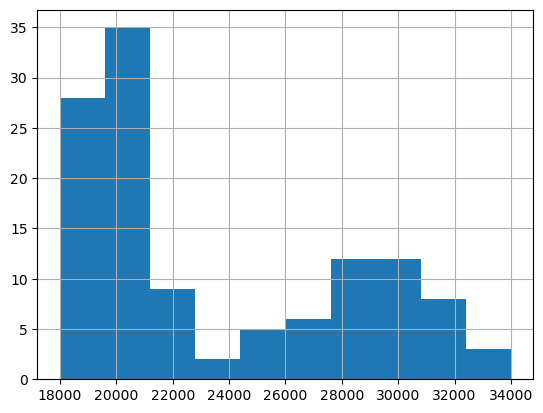

In [5]:
df[target].hist()

#### Check data type

In [6]:
df.dtypes

Date          object
GPT(THB)       int64
GPW(USD)     float64
CPI          float64
IR           float64
POIL(USD)    float64
EXR          float64
dtype: object

#### Clean missing value

In [7]:
missing_values = df.isnull().sum()

#### Relationship

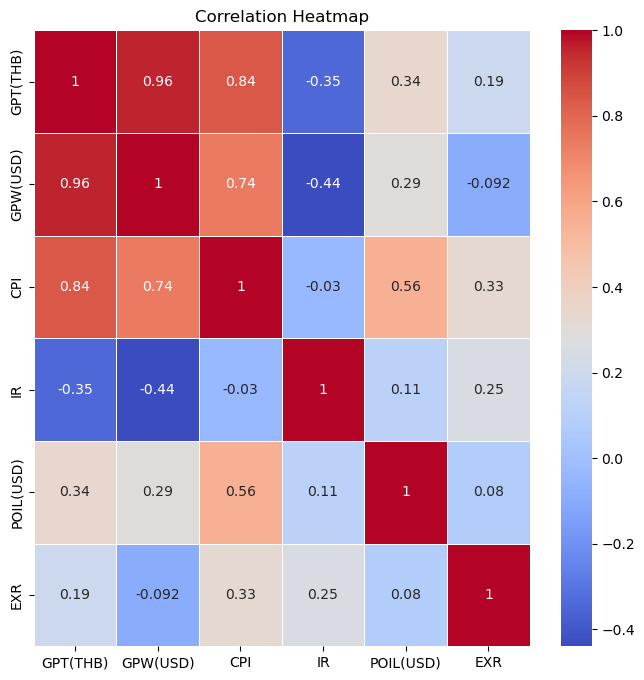

In [8]:
correlation_matrix = df[['GPT(THB)','GPW(USD)', 'CPI','IR','POIL(USD)','EXR']].corr()

plt.figure(figsize=(8,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

#### Assign target and features

In [9]:
features = ['GPW(USD)', 'CPI', 'IR', 'POIL(USD)', 'EXR']

In [10]:
y = df[target]
X = df[features]

### Split dataset

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [12]:
X_train

,GPW(USD),CPI,IR,POIL(USD),EXR
30,1335.75,97.77,1.50,41.12,35.0706
53,1247.74,99.42,1.50,71.66,32.4702
118,2044.80,107.45,2.50,77.79,35.4656
9,1198.91,98.35,2.00,81.04,32.4575
33,1278.01,97.92,1.50,48.25,35.0603
...,...,...,...,...,...
106,1749.82,107.92,1.25,78.98,36.4265
14,1185.40,97.45,1.75,48.73,32.6340
92,1726.40,101.21,0.50,74.47,33.1190
51,1322.81,98.95,1.50,68.04,31.3148


In [13]:
y_train

30     22200
53     19650
118    33900
9      18150
33     21150
       ...  
106    29450
14     18200
92     27750
51     19700
102    30300
Name: GPT(THB), Length: 84, dtype: int64

### Feature selection

#### Step-wise

In [14]:
def stepwise(X, y, threshold_in=0.05, threshold_out=0.05):
    """
    Stepwise regression forr Linear Regression model.
    """
    included = []

    while True:
        changed = False

        # Forward Step
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded)

        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]

        best_pval = new_pval.min()

        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True

            print(f'Add {best_feature} with p-value {best_pval}')

        # Backward Step
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max()

        if worst_pval > threshold_out:
            changed = True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)

            print(f'Drop {worst_feature} with p-value {worst_pval}')

        if not changed:
            break

    return included

In [15]:
features = stepwise(X_train, y_train)

Add GPW(USD) with p-value 1.6592163316594983e-44
Add EXR with p-value 2.0455836117430443e-46
Add CPI with p-value 3.3538494708532755e-05


In [16]:
features

['GPW(USD)', 'EXR', 'CPI']

In [17]:
X_train = X_train[features]
X_test = X_test[features]

In [18]:
X_train

,GPW(USD),EXR,CPI
30,1335.75,35.0706,97.77
53,1247.74,32.4702,99.42
118,2044.80,35.4656,107.45
9,1198.91,32.4575,98.35
33,1278.01,35.0603,97.92
...,...,...,...
106,1749.82,36.4265,107.92
14,1185.40,32.6340,97.45
92,1726.40,33.1190,101.21
51,1322.81,31.3148,98.95


### Feature engineering

#### Standardization

In [19]:
scaler = StandardScaler()

In [20]:
train_index = X_train.index
X_train_scale = pd.DataFrame(scaler.fit_transform(X_train), columns=features)
X_train_scale.index = train_index

In [21]:
X_train

,GPW(USD),EXR,CPI
30,1335.75,35.0706,97.77
53,1247.74,32.4702,99.42
118,2044.80,35.4656,107.45
9,1198.91,32.4575,98.35
33,1278.01,35.0603,97.92
...,...,...,...
106,1749.82,36.4265,107.92
14,1185.40,32.6340,97.45
92,1726.40,33.1190,101.21
51,1322.81,31.3148,98.95


In [22]:
test_index = X_test.index
X_test_scale = pd.DataFrame(scaler.transform(X_test), columns=features)
X_test_scale.index = test_index

## Model

### First training

In [23]:
model = sm.OLS(y_train, sm.add_constant(X_train_scale)).fit()

In [24]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               GPT(THB)   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     4597.
Date:                Fri, 03 Jul 2026   Prob (F-statistic):           1.97e-89
Time:                        08:56:37   Log-Likelihood:                -615.05
No. Observations:                  84   AIC:                             1238.
Df Residuals:                      80   BIC:                             1248.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.375e+04     40.940    580.167      0.000    2.37e+04    2.38e+04
GPW(USD)    4407.7967     74.142     59.451      0.000    4260.250    4555.344
EXR         1251.3595     52.547     23.814      0.000    1146.787    1355.932
CPI          349.9013     79.589      4.396      0.000     191.513     508.289
==============================================================================
Omnibus:                        5.320   Durbin-Watson:                   2.186
Prob(Omnibus):                  0.070   Jarque-Bera (JB):                7.612
Skew:                           0.081   Prob(JB):                       0.0222
Kurtosis:                       4.466   Cond. No.                         3.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [25]:
y_pred = model.predict(sm.add_constant(X_test_scale))
residuals = y_test - y_pred

### Check assumption

#### Linearity

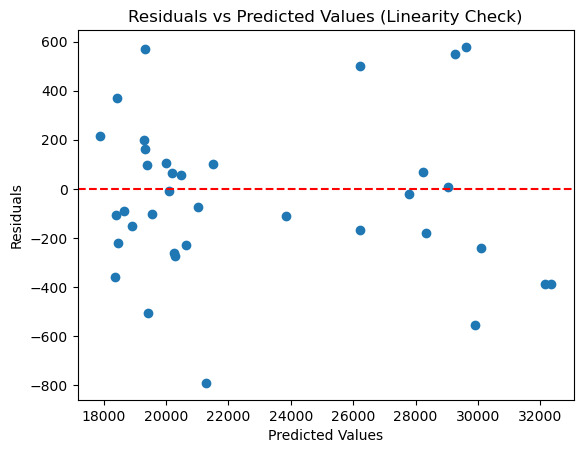

In [26]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values (Linearity Check)')
plt.show()

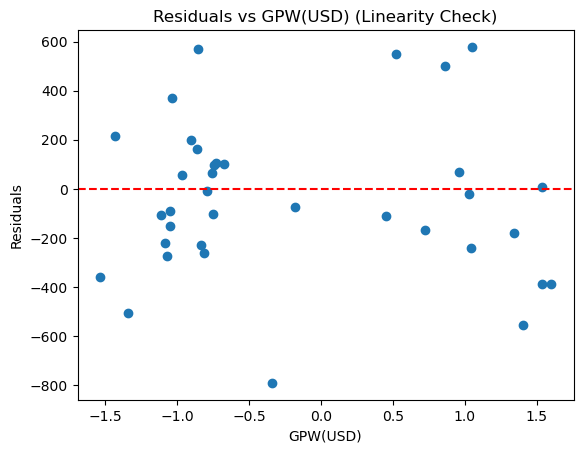

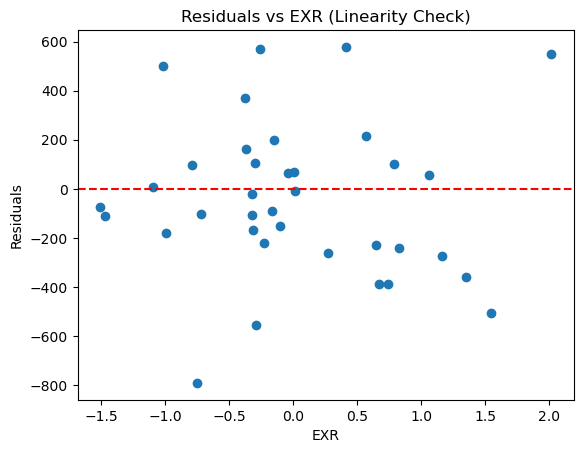

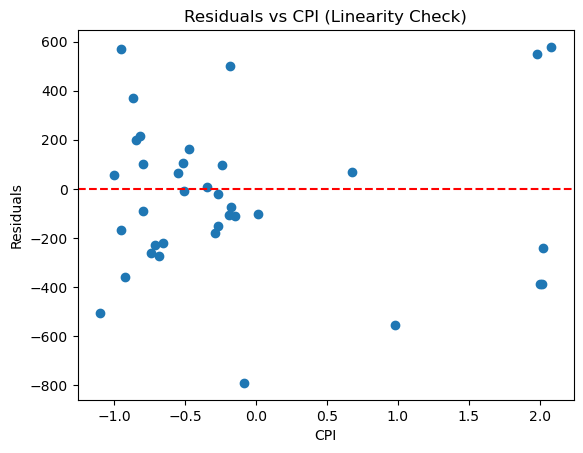

In [27]:
for feature in features:
    plt.scatter(X_test_scale[feature], residuals)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f'Residuals vs {feature} (Linearity Check)')
    plt.xlabel(feature)
    plt.ylabel('Residuals')
    plt.show()

#### Independence

In [28]:
dw_test = durbin_watson(residuals)
print(f"Durbin-Watson test statistic: {dw_test}")

Durbin-Watson test statistic: 2.0266450785784933


#### Homoscedasticity

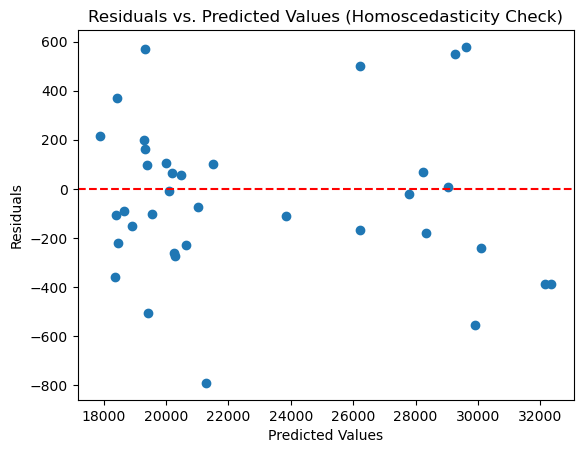

In [29]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values (Homoscedasticity Check)')
plt.show()

#### Normality of residuals

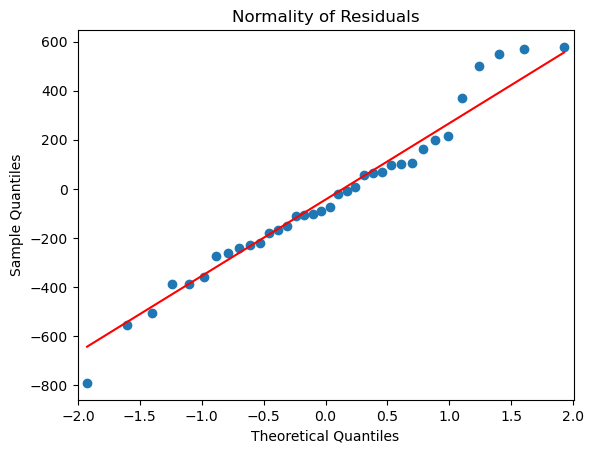

In [30]:
sm.qqplot(residuals, line='s')
plt.title('Normality of Residuals')
plt.show()

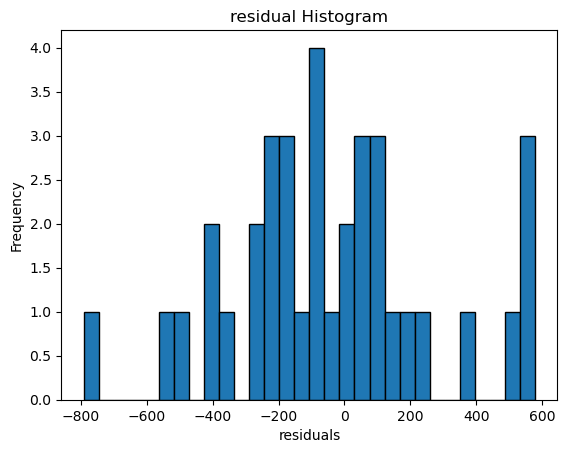

In [31]:
plt.hist(residuals, bins=30, edgecolor='k')
plt.title('residual Histogram')
plt.xlabel('residuals')
plt.ylabel('Frequency')
plt.show()

In [32]:
shapiro_test = shapiro(residuals)
print(f"Shapiro-Wilk test for normality: {shapiro_test}")

Shapiro-Wilk test for normality: ShapiroResult(statistic=0.9737919533991123, pvalue=0.5377673947157526)


#### Multicollinearity

In [33]:
X_vif = sm.add_constant(X_train_scale[features])
vif = pd.DataFrame()
vif['features'] = X_train_scale[features].columns
vif['VIF'] = [variance_inflation_factor(X_vif, i + 1) for i in range(len(X_train_scale[features].columns))]
print(vif)

   features       VIF
0  GPW(USD)  3.279745
1       EXR  1.647448
2       CPI  3.779413


#### Model training

In [34]:
model = sm.OLS(y_train, sm.add_constant(X_train_scale)).fit()

In [35]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               GPT(THB)   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     4597.
Date:                Fri, 03 Jul 2026   Prob (F-statistic):           1.97e-89
Time:                        08:56:41   Log-Likelihood:                -615.05
No. Observations:                  84   AIC:                             1238.
Df Residuals:                      80   BIC:                             1248.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.375e+04     40.940    580.167      0.000    2.37e+04    2.38e+04
GPW(USD)    4407.7967     74.142     59.451      0.000    4260.250    4555.344
EXR         1251.3595     52.547     23.814      0.000    1146.787    1355.932
CPI          349.9013     79.589      4.396      0.000     191.513     508.289
==============================================================================
Omnibus:                        5.320   Durbin-Watson:                   2.186
Prob(Omnibus):                  0.070   Jarque-Bera (JB):                7.612
Skew:                           0.081   Prob(JB):                       0.0222
Kurtosis:                       4.466   Cond. No.                         3.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [36]:
y_pred = model.predict(sm.add_constant(X_test_scale))
residuals = y_test - y_pred

## Evaluate

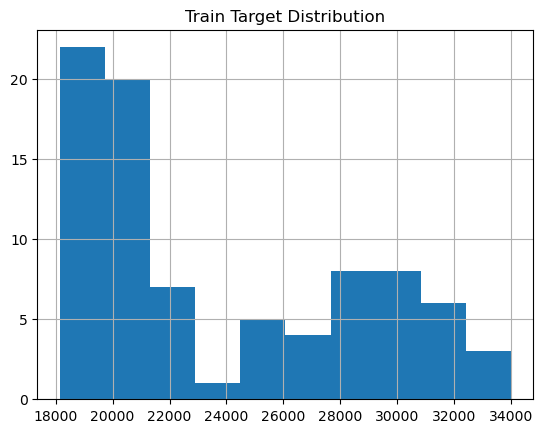

In [37]:
y_train.hist()
plt.title('Train Target Distribution')
plt.show()

In [38]:
y_pred_train = model.predict(sm.add_constant(X_train_scale))
mean_squared_error(y_pred_train, y_train)

134083.6742551935

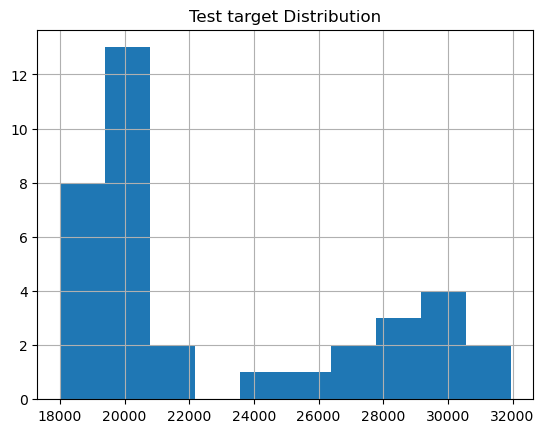

In [39]:
y_test.hist()
plt.title('Test target Distribution')
plt.show()

In [40]:
mean_squared_error(y_pred, y_test)

98671.87751359431

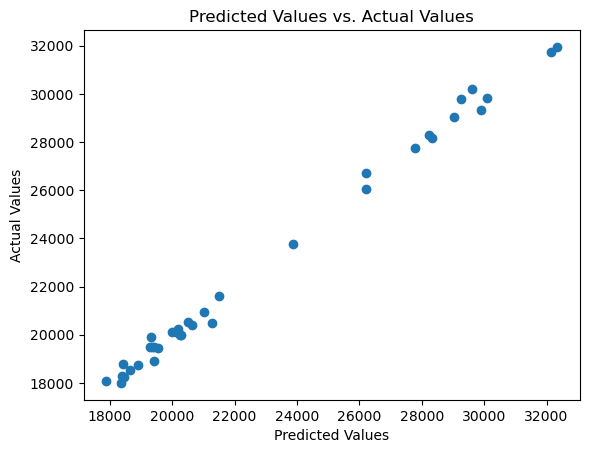

In [41]:
plt.scatter(y_pred, y_test)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Predicted Values vs. Actual Values')
plt.show()